# Imports

In [133]:
# Imports
import numpy as np
from numpy import nan
import pandas as pd
import matplotlib.pyplot as plt
import os
import scipy
import scipy.stats as stats
from scipy.spatial.distance import cdist
import itertools
from tqdm.auto import tqdm
import seaborn as sns
import importlib
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import bernoulli
import warnings
from GP import *
from plotter import *
from scipy.special import softmax
from scipy.spatial.distance import cdist

# 2AFC

## Simulations

  0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

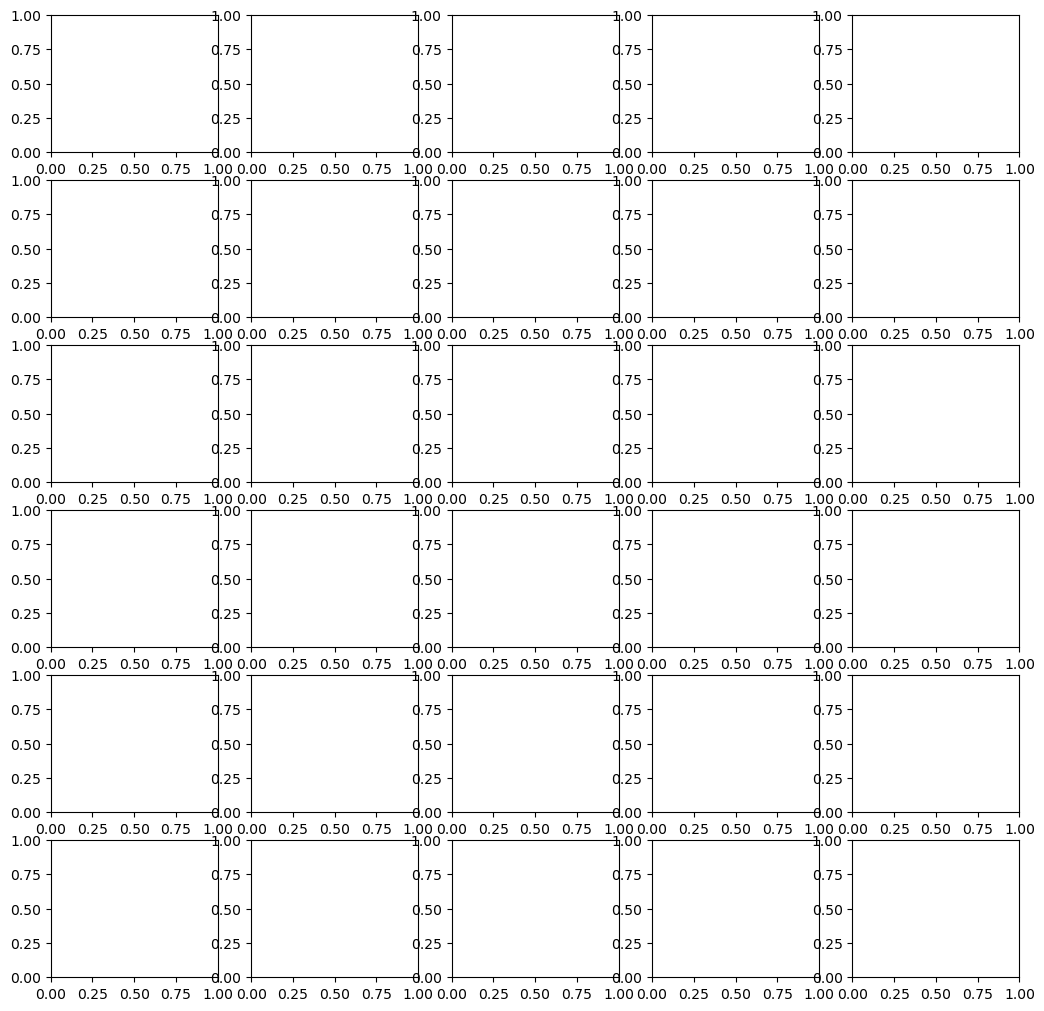

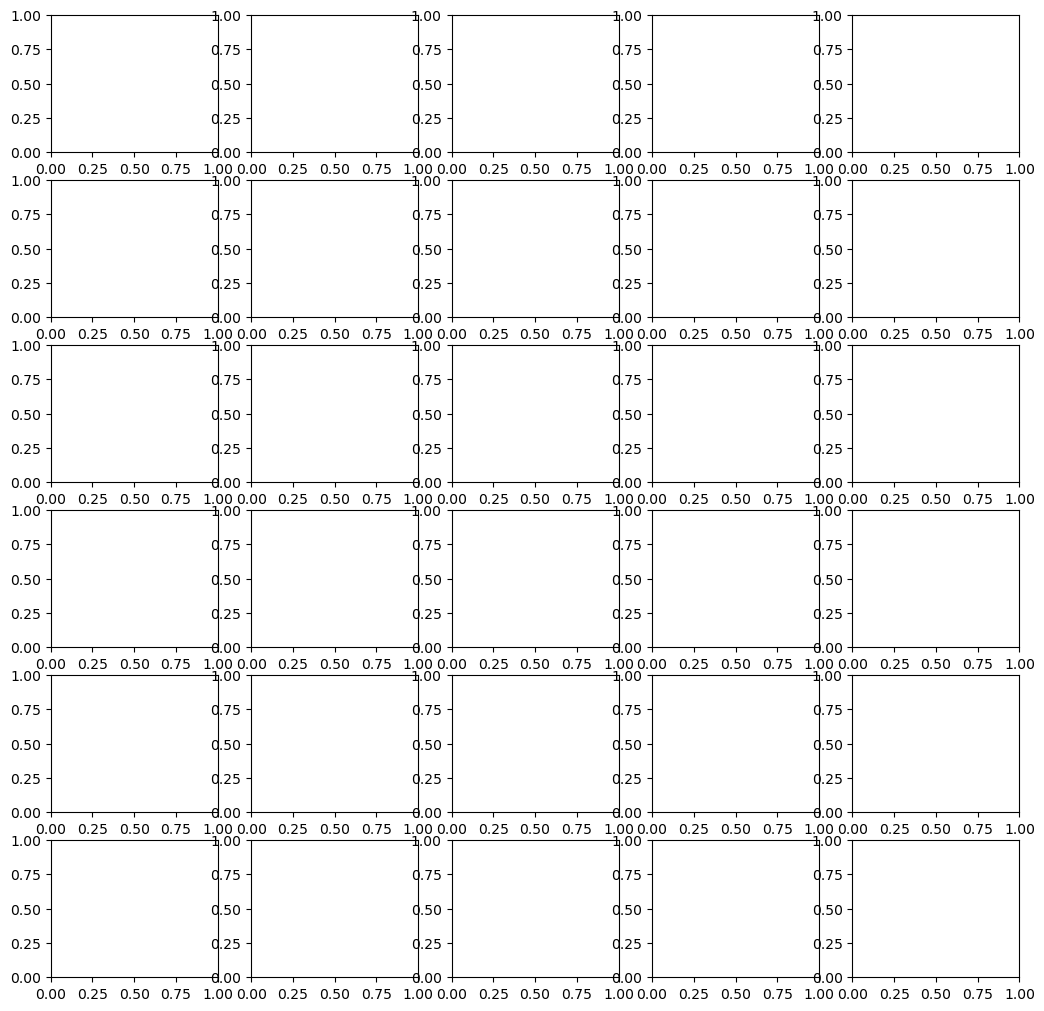

In [269]:
import GP
importlib.reload(GP)
from GP import *

import plotter
importlib.reload(plotter)
from plotter import *

### zero in on interesting combos

## inititialise the GP
N = 10
c = [1]
scale = [1]
theta = [0]
sigma_f = [1]
length_scale = [N/2.5]
# length_scale = np.linspace(1,10,5, dtype = int)
period = [4]
# period = np.linspace(1,10,10)
periodic_length_scale = [4]
# periodic_length_scale = [N/2.5]
# periodic_length_scale = np.linspace(1,10,10)
# periodic_theta = [0]
periodic_theta = [np.pi/4]
# GP_params = [c, scale, theta, sigma_f, length_scale, period, periodic_length_scale, periodic_theta]
param_combos = list(itertools.product(c, scale, theta, sigma_f, length_scale, period, periodic_length_scale, periodic_theta))
param_names = ['c', 'scale', 'theta', 'sigma_f', 'length_scale', 'period', 'periodic_length_scale', 'periodic_theta']

## init dict to store data
gp_dict = {
    'gen_kernel': [],
    'inf_kernel': [],
    'n_obs': [],
    'trial': [],
    'k_mll': [],
    'x_1': [],
    'x_2': [],
    'reward_1': [],
    'reward_2': [],
    'CP_1': [],
    'CP_2': [],
    'p(correct)': []
}
for param in param_names:
    gp_dict[param] = []

## loop through parameter initialisations
for pci in tqdm(range(len(param_combos))):
    params = param_combos[pci]

    ## define koi
    gp = GP_world(N, params)
    koi = [
        
        ## base kernels
        # gp.K_lin,
        gp.K_lin_x,
        gp.K_lin_y,
        # gp.K_rbf,
        # gp.K_rbf_x,
        # gp.K_rbf_y,
        gp.K_periodic_x,
        # gp.K_periodic_y,


        ## combos
        # gp.K_lin*gp.K_periodic_x,
        # gp.K_lin*gp.K_periodic_y,
        gp.K_lin_x*gp.K_periodic_x,
        gp.K_lin_y*gp.K_periodic_x,
        # gp.K_rbf_x*gp.K_periodic_x,
        # gp.K_rbf_y*gp.K_periodic_x,
        # gp.K_periodic_x*gp.K_periodic_y
    ]

    kernel_names = [
        ## base kernels
        # 'Linear',
        'Linear_x',
        'Linear_y',
        # 'RBF',
        # 'RBF_x',
        # 'RBF_y',
        # 'Periodic_x',
        # 'Periodic_y',
        'Periodic_diag',

        ## combos
        # 'Linear*Periodic_x',
        # 'Linear*Periodic_y',
        'Linear_x*Periodic_x',
        'Linear_y*Periodic_x',
        # 'RBF_x*Periodic_diag',
        # 'RBF_y*Periodic_diag',
        # 'Periodic_x*Periodic_y'
    ]


    ## init plots 
    n_k = len(koi)
    n_trials = 500
    if (pci == len(param_combos)-1):
        fig, axs = plt.subplots(n_k+1,n_k, figsize=(n_k*2.5,n_k*2.5))
        fig2, axs2 = plt.subplots(n_k+1,n_k, figsize=(n_k*2.5,n_k*2.5))



    ## loop through combos
    for kg, k_gen in enumerate(koi):
        k_gen_name = kernel_names[kg]
        gp.k_check(k_gen)

        ## loop through trials
        for t in range(n_trials):
        
            ## sample from combo kernel
            samples = gp.sample(k_gen)

            ## generate observations
            n_obs = 10
            all_obs = gp.gen_obs(samples, n_obs)
            
            ## for each trial, select two random points to choose between
            preds = gp.gen_preds(samples).squeeze()


            ## plot
            if (t == n_trials-1) & (pci == len(param_combos)-1):
                plot_r(samples, axs[0,kg], k_gen_name, cbar = kg==(len(koi)-1))
                plot_r(samples, axs2[0,kg], k_gen_name, cbar = kg==(len(koi)-1))
                plot_obs(all_obs, axs[0,kg], text=False)
                plot_obs(all_obs, axs2[0,kg], text=False)
            
            ## loop through inference kernels
            for ki, k_inf in enumerate(koi):
                k_inf_name = kernel_names[ki]

                ## incrementally increase the number of observations
                for o in range(n_obs):
                    obs = all_obs[:o+1]

                    ## calculate posterior of the points to compare, given the observations made so far
                    post_mean, post_cov = gp.post_pred(k_inf, obs, preds[:,0].astype(int))
                    # temp = 0.1
                    # choice_prob = softmax(post_mean/temp)
                    # choice_prob = gp.sigmoid(diff, tau)
                    choice_prob = [scipy.stats.norm.cdf(post_mean[0]-post_mean[1], 0, np.sum(np.diag(post_cov)))]
                    choice_prob.append(1-choice_prob[0])


                    ## compute log marginal likelihood under this kernel
                    ll = gp.likelihood(k_inf, obs)

                    ## save data
                    gp_dict['gen_kernel'].append(k_gen_name)
                    gp_dict['inf_kernel'].append(k_inf_name)
                    gp_dict['trial'].append(t)
                    gp_dict['k_mll'].append(ll)
                    gp_dict['n_obs'].append(o+1)
                    ## should also save the info about the observations somewhere
                    gp_dict['x_1'].append(preds[0,0])
                    gp_dict['x_2'].append(preds[1,0])
                    gp_dict['reward_1'].append(preds[0,-1])
                    gp_dict['reward_2'].append(preds[1,-1])
                    gp_dict['CP_1'].append(choice_prob[0])
                    gp_dict['CP_2'].append(choice_prob[1])
                    gp_dict['p(correct)'].append(choice_prob[np.argmax(preds[:,-1])])

                    ## save params
                    for param in param_names:
                        gp_dict[param].append(params[param_names.index(param)])
                
                ## plot the full posterior distribution once all observations have been made
                full_post_mean, _ = gp.post_pred(k_inf, obs)
                if (t == n_trials-1) & (pci == len(param_combos)-1):
                    plot_r(full_post_mean.reshape(N,N), axs[ki+1,kg], cbar = kg==(len(koi)-1))
                    RPE = samples-full_post_mean.reshape(N,N)
                    plot_RPE(RPE, axs2[ki+1,kg], cbar = (kg==(len(koi)-1)))
            

        ## loop through rows and add y-axis to the leftmost column
        if (t == n_trials-1) & (pci == len(param_combos)-1):
            for i in range(n_k):
                axs[i+1,0].set_ylabel(kernel_names[i])
                axs2[i+1,0].set_ylabel(kernel_names[i])

    ## convert ll_dict to df
    df_gp = pd.DataFrame(gp_dict)

## Plots

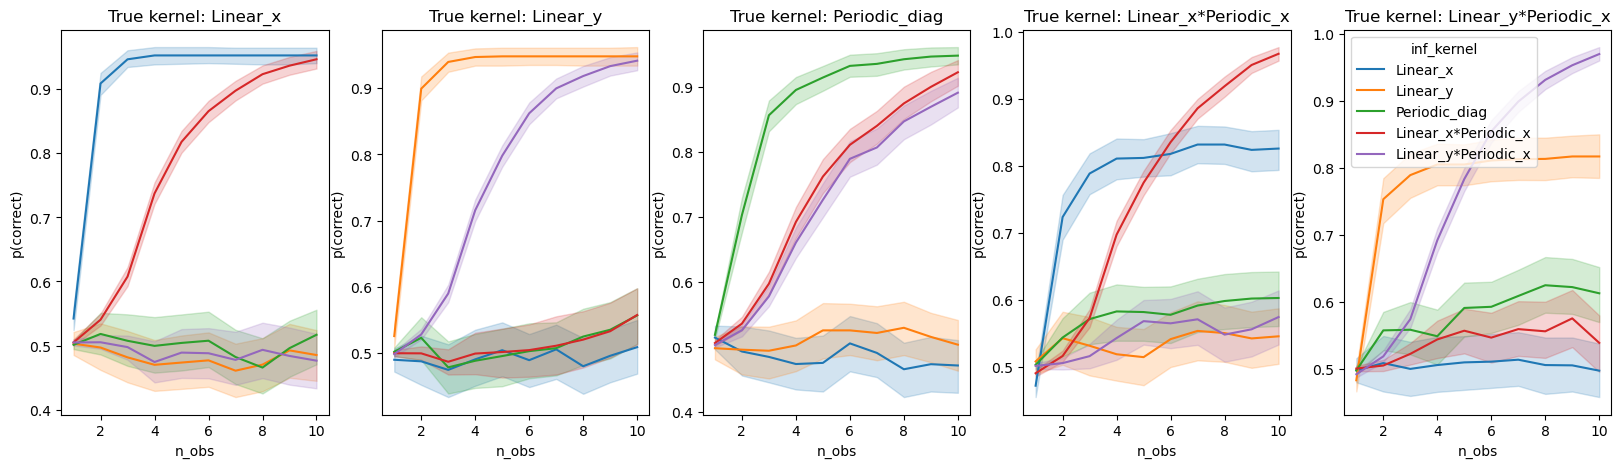

In [6]:
## accuracy

# param_of_interest = scale.copy()
# param_of_interest = length_scale.copy()
# param_of_interest = period.copy()
param_of_interest = periodic_length_scale.copy()
for p in periodic_length_scale:
    data_tmp = df_gp.loc[df_gp['periodic_length_scale']==p]
    fig, axs = plt.subplots(1, n_k, figsize=(4*n_k, 5))
    for gki, gen_k in enumerate(data_tmp['gen_kernel'].unique()):
        sns.lineplot(data = data_tmp.loc[data_tmp['gen_kernel']==gen_k], x = 'n_obs', y = 'p(correct)', hue = 'inf_kernel', ax = axs[gki], legend = gki==n_k-1)
        axs[gki].set_title('True kernel: '+gen_k)
    # plt.suptitle((p))


## MLL

fig, axs = plt.subplots(1,n_k, figsize=(20,5))
for i in range(n_k):
    sns.lineplot(data = df_gp.loc[df_gp['gen_kernel'] == kernel_names[i]], x = 'n_obs', y = 'k_mll', hue = 'inf_kernel', ax = axs[i], legend=i==0, )
    axs[i].set_title('True kernel: '+kernel_names[i])
    axs[i].set_xlabel('N obs')
    axs[i].set_ylabel('')
    # axs[i].set_ylim(-100,25)
axs[0].set_ylabel('log marginal likelihood')
# axs[-1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

## Trajectories

In [306]:
import GP
importlib.reload(GP)
from GP import *

import plotter
importlib.reload(plotter)
from plotter import *

# ## inititialise the GP
# N = 10
# c = [1]
# scale = [1]
# theta = [0]
# sigma_f = [1]
# length_scale = [N/2.5]
# # length_scale = np.linspace(1,10,5, dtype = int)
# period = [4]
# # period = np.linspace(1,10,10)
# periodic_length_scale = [4]
# # periodic_length_scale = [N/2.5]
# # periodic_length_scale = np.linspace(1,10,10)
# # periodic_theta = [0]
# periodic_theta = [np.pi/4]
# # GP_params = [c, scale, theta, sigma_f, length_scale, period, periodic_length_scale, periodic_theta]
# param_combos = list(itertools.product(c, scale, theta, sigma_f, length_scale, period, periodic_length_scale, periodic_theta))
# param_names = ['c', 'scale', 'theta', 'sigma_f', 'length_scale', 'period', 'periodic_length_scale', 'periodic_theta']


# params = param_combos[0]

gp = GP_world(N, params)
pair = preds[:,1:3]
for metric in ['chebyshev', 'manhattan']:
    traj, route_reward  = gp.trajectory(pair,samples,metric)
    print(metric, len(traj), np.sum(route_reward))


# samples[traj[0:2]]
# r,c = zip(*traj)
# print(samples[r,c])
# [samples[r,c] for r,c in traj]

chebyshev 5 2.777777539417731
manhattan 9 5.888889239609113


[14 58]
(array([1, 5]), array([4, 8]))
euclidean 5.656854249492381
cityblock 8.0
chebyshev 4.0


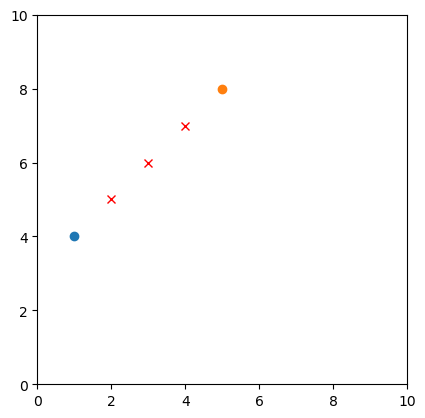

In [247]:
def trajectory(start, end, metric = 'chebyshev'):
    
    ## convert start and end points to 2D coordinates
    start = np.unravel_index(start, (10,10))
    end = np.unravel_index(end, (10,10))
    x1, y1 = start
    x2, y2 = end
    trajectory = [start]
    
    ## allow agent to move diagonally
    if metric == 'chebyshev':
        while trajectory[-1] != end:
            
            ## determine direction of movement
            dx = np.sign(x2 - x1)  # -1, 0, or 1 for x direction
            dy = np.sign(y2 - y1)  # -1, 0, or 1 for y direction
            
            # Move in the direction of the target (i.e. diag if both dx and dy are non-zero)
            x1, y1 = (x1 + dx, y1 + dy)
            trajectory.append((x1, y1))

    ## only allow agent to move in cardinal directions
    elif metric == 'manhattan':
        
        # first move in x direction
        while x1 != x2:
            if x2 > x1:
                x1 += 1  # Move right
            else:
                x1 -= 1  # Move left
            trajectory.append((x1, y1))
        
        # Then, move vertically until y1 == y2
        while y1 != y2:
            if y2 > y1:
                y1 += 1  # Move up
            else:
                y1 -= 1  # Move down
            trajectory.append((x1, y1))
    
    return trajectory


## calulate distance between two random points in the grid 
dist_metrics = [
    'euclidean',
    'cityblock',
    'chebyshev'
]
pair = np.random.randint(0, N**2, (2))
print(pair)
print(np.unravel_index(pair, (N,N)))

## plot square grid
plt.figure()
for p in pair:
    p = np.unravel_index(p, (N,N))
    plt.plot(p[0], p[1], 'o')
plt.xlim(0,10)
plt.ylim(0,10)
plt.gca().set_aspect('equal', adjustable='box')
for met in dist_metrics:
    all_dists = scipy.spatial.distance.cdist(gp.locations, gp.locations, metric = met)
    dist = all_dists[pair[0], pair[1]]
    print(met, dist)

# Get the trajectory
traj = trajectory(pair[0], pair[1])
for t in traj[1:-1]:
    plt.plot(t[0], t[1], 'x', color='red')